# Pytorch Force Inference Code

This notebook demonstrates how to use the refactored `GNN_inference` module step-by-step.

This is an adaptation of Billie's force inference code, converting it from tensorflow to pytorch for the first example dataset from simulation.

In [280]:
# Enable autoreload so module changes are automatically reloaded
%load_ext autoreload
%autoreload 2

# Import everything from the module
import sys
sys.path.append('..')
# from ForSean.GNN_inference import *

import importlib
import torch
import torch.nn as nn

import torch_inference
importlib.reload(torch_inference)
from torch_inference import *

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
# auto-reload the module

clrs = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b', '#e377c2', '#7f7f7f', '#bcbd22', '#17becf']
cmap = sns.color_palette("viridis", as_cmap=True)


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Load and Prepare Data


In [281]:
## Note: change datadir to your own path
#dataname = "output_Test.csv" #for sure variable nodes
dataname = "output_kappa0.2_temp0.1_trajlen300_dt0.01_N15_seed1_damp50frame10.csv"
#dataname = "outputVariableNodes_kappa0.2_temp0.1_trajlen300_dt0.01_N20_seed1_damp50frame10.csv"
datadir = '//Users/billiemeadowcroft/Dropbox/PostDocCode/Github_SFI/ForDuke/UD_Inference/Data_CSVs/'
data = load_data(datadir, dataname)

Data loaded: (4365, 6)
Columns: ['frame', 'particle', 'x', 'y', 'z', 'mass']
Number of frames: 301


## Calculate derivatives (velocities and accelerations)


In [282]:
frame = 10
delta_t = 0.01
dt = delta_t*frame
T_weak = False #False #True
T_Naive = True
tau = 16
print("length of data: ", len(data))
print("Total unique particles: ", len(data['particle'].unique()))
print("for naive derivative, should be losing 2x the number of particles",len(data)-len(data['particle'].unique())*2)
data_clean = calculate_derivatives(data, dt=dt,weak_form = T_weak,naive_form = T_Naive,tau = 6)
#how much of the total data has zero ax and ay?
print(f"Fraction of data with zero ax and ay: {len(data_clean[data_clean['ax'] == 0])/len(data_clean)}")

#data_clean = data_clean[data_clean['ax'] != 0]
#data_clean = data_clean[data_clean['ay'] != 0]
print(f"Fraction of data with non-zero ax and ay: {len(data_clean[data_clean['ax'] != 0])/len(data_clean)}")
print("Length of data_clean: ", len(data_clean))

length of data:  4365
Total unique particles:  18
for naive derivative, should be losing 2x the number of particles 4329
Calculating derivatives...
Processing 18 particles...
Calculating naïve derivatives...
Acceleration statistics:
  ax: mean=0.002, std=0.687
  ay: mean=0.001, std=0.652
Fraction of data with zero ax and ay: 0.008247422680412371
Fraction of data with non-zero ax and ay: 0.9917525773195877
Length of data_clean:  4365


## (optional) Plotting some acceleration data of a single particle


0        1
1        2
2        3
3        4
4        5
        ..
4360    14
4361    15
4362    16
4363    17
4364    18
Name: particle, Length: 4365, dtype: int64
    frame  particle        x        y         z  mass      vx      vy     ax  \
4       0         5 -1.43932 -1.18594  0.004010   1.0  0.0000  0.0000  0.000   
19      1         5 -1.46835 -1.18812 -0.047231   1.0 -0.2903 -0.0218 -0.156   
34      2         5 -1.49894 -1.18497 -0.101574   1.0 -0.3059  0.0315 -0.285   
49      3         5 -1.53238 -1.17598  0.041287   1.0 -0.3344  0.0899 -0.012   
64      4         5 -1.56594 -1.16358 -0.015147   1.0 -0.3356  0.1240  0.339   

       ay  
4   0.000  
19  0.533  
34  0.584  
49  0.341  
64  0.032  


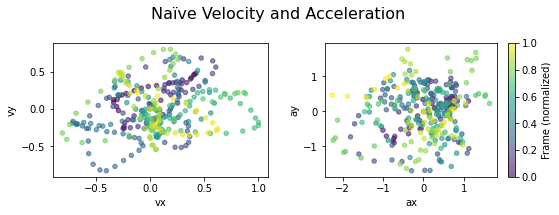

In [283]:

print(data_clean['particle'])
N=5
data_1particle = data_clean[data_clean['particle'] == N]
print(data_1particle.head())

fig,ax = plt.subplots(1,2,figsize=(8,3))
cmap = plt.cm.viridis
normalized_frames = (data_1particle['frame'] - data_1particle['frame'].min()) / \
                    (data_1particle['frame'].max() - data_1particle['frame'].min())
ax[0].scatter(data_1particle['vx'],data_1particle['vy'],
              c=normalized_frames, cmap=cmap, s=20, alpha=0.6)
ax[0].set_xlabel('vx')
ax[0].set_ylabel('vy')
ax[1].scatter(data_1particle['ax'], data_1particle['ay'], 
              c=normalized_frames, cmap=cmap, s=20, alpha=0.6)
ax[1].set_xlabel('ax')
ax[1].set_ylabel('ay')
plt.colorbar(ax[1].collections[0],label='Frame (normalized)')
#ax[0].plot(data_clean['ay'],color = clrs[1],linestyle = '--',label = 'ay')
# put central title for whole figure
if T_Naive:
    fig.suptitle('Naïve Velocity and Acceleration', fontsize=16)
else:
    fig.suptitle(r'Weak form Velocity and Acceleration for $\tau =$'+str(tau), fontsize=16)
fig.tight_layout()
scale = 1
if T_weak and T_Naive:
    fig,ax = plt.subplots(1,2,figsize=(8,3))
    cmap = plt.cm.viridis
    normalized_frames = (data_1particle['frame'] - data_1particle['frame'].min()) / \
                        (data_1particle['frame'].max() - data_1particle['frame'].min())
    ax[0].scatter(np.multiply(data_1particle['Wvx'],scale),np.multiply(data_1particle['Wvy'],scale),
                c=normalized_frames, cmap=cmap, s=20, alpha=0.6)
    ax[0].set_xlabel('Wvx')
    ax[0].set_ylabel('Wvy')
    ax[1].scatter(data_1particle['Wax'], data_1particle['Way'], 
                c=normalized_frames, cmap=cmap, s=20, alpha=0.6)
    ax[1].set_xlabel('Wax')
    ax[1].set_ylabel('Way')
    plt.colorbar(ax[1].collections[0],label='Frame (normalized)')
    #ax[0].plot(data_clean['ay'],color = clrs[1],linestyle = '--',label = 'ay')
    # put central title for whole figure
    fig.suptitle(r'Weak form Velocity and Acceleration for $\tau = $'+str(tau), fontsize=16)
    fig.tight_layout()
    ax[1].set_xlabel('ax')
    ax[1].set_ylabel('ay')
    ax[1].set_ylim([-2,2])
    ax[1].set_xlim([-2,2])
    ax[0].set_ylim([-1.2,1.2])
    ax[0].set_xlim([-1.2,1.2])

## Visualize All Trajectories

In [284]:
IndexFrame = data.frame.unique()
IndexFrame.sort()
data['frame'] = data['frame'].map(dict(zip(IndexFrame, range(len(IndexFrame)))))
data = data.sort_values(by='frame')
data = data.sort_values(by='particle').reset_index(drop=True)
CellInd = data.index[data['particle'].diff().ne(0)].tolist()
CellInd.append(len(data) - 1) 

Number of cells =  18


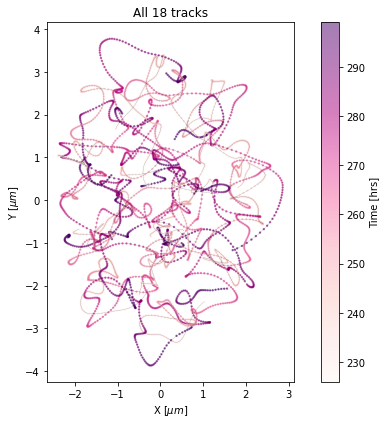

In [285]:
# first plot all the cells
fig,ax = plt.subplots(1,figsize=(8.5,6))
print("Number of cells = ",len(CellInd)-1)
count=0
CellNumCh =len(CellInd)
counter2 = 0
for cell in range(CellNumCh-1):
    ci = cell
    Tstart = CellInd[ci]+1
    Tend = CellInd[ci+1]
    MaxTime = data.frame.max()
    trajectory_data = data.iloc[Tstart:Tend]
    trajectory_data = trajectory_data.sort_values(by='frame')
    if len(trajectory_data.frame.unique()) != len(trajectory_data.frame):
        counter2 +=1
        continue
    count+=1
    line = ax.plot(
        trajectory_data.x, 
        trajectory_data.y, 
        color='black',  # Set the color of the line
        linewidth=0.1,  # Set the line width
        linestyle='-',  # Set the line style
    )
    sc = ax.scatter(
        trajectory_data.x, 
        trajectory_data.y, 
        #c = clrs[cell],
        label = cell,
        c=trajectory_data.frame,  # Use EDGE_TIME for color mapping
        cmap='RdPu',  # Set the colormap
        s=2,  # Set marker size
        alpha = 0.5,
    )

plt.colorbar(sc, ax=ax, label='Time [hrs]')
ax.set_xlabel(r'X [$\mu m$]')  
ax.set_ylabel(r'Y [$\mu m$]')
ax.set_title('All '+str(len(CellInd)-1)+' tracks')
fig.tight_layout()  
ax.set_aspect('equal')


In [ ]:
# Prepare dataset with graph structure
dataset = prepare_dataset(data_clean, cutoff=3.0, max_frames=300,use_neighbor_list=False)

Preparing dataset from 300 frames...
processing frame  0
processing frame  1
processing frame  2
processing frame  3
processing frame  4
processing frame  5
processing frame  6
processing frame  7
processing frame  8
processing frame  9
processing frame  10
processing frame  11
processing frame  12
processing frame  13
processing frame  14
processing frame  15
processing frame  16
processing frame  17
processing frame  18
processing frame  19
processing frame  20
processing frame  21
processing frame  22
processing frame  23
processing frame  24
processing frame  25
processing frame  26
processing frame  27
processing frame  28
processing frame  29
processing frame  30
processing frame  31
processing frame  32
processing frame  33
processing frame  34
processing frame  35
processing frame  36
processing frame  37
processing frame  38
processing frame  39
processing frame  40
processing frame  41
processing frame  42
processing frame  43
processing frame  44
processing frame  45
process

## Split dataset

In [287]:
train_data, val_data, test_data, __ = split_dataset(dataset, train_frac=0.7, val_frac=0.15)

Data splits:
  Train: 210
  Val:   45
  Test:  45


## (Optional) Plot an example graph of one frame (Check connectivity)

Text(0.5, 1.0, 'Graph')

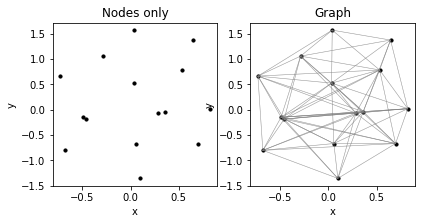

In [288]:
fig, ax = plt.subplots(1, 2, figsize=(6.5, 3))

# Get first frame from train_data
frame_data = train_data[0]  # Fixed: get first element of list

# Plot nodes on both subplots
for i in range(2):
    ax[i].scatter(frame_data['nodes'][:, 0], frame_data['nodes'][:, 1], 
                  color='black', s=10)
    ax[i].set_xlabel('x')
    ax[i].set_ylabel('y')
    #ax[i].set_aspect('equal')

# Plot edges on second subplot
edges = frame_data['edges']
for i in range(edges.shape[1]):
    source_idx = edges[0, i]
    target_idx = edges[1, i]
    
    # Get positions
    x_source, y_source = frame_data['nodes'][source_idx][:2] #first two node features are position
    x_target, y_target = frame_data['nodes'][target_idx][:2]
    
    # Plot line from source to target
    ax[1].plot([x_source, x_target], 
               [y_source, y_target], 
               color='gray', alpha=0.5, linewidth=0.5)

ax[0].set_title('Nodes only')
ax[1].set_title('Graph')
# fig.tight_layout()
# ax[0].set_aspect('equal')
# ax[1].set_aspect('equal')

## Create and Train Model


In [265]:
class ForceGNN(nn.Module):
    """
    Graph Neural Network for learning force decomposition.
    
    Forces are decomposed into:
    - F_env: Environmental/external forces (position-dependent, uses node_features[:, :2])
    - F_r: Pairwise interaction forces (distance-dependent)
    - γ * v: Drag/friction term (velocity-dependent, uses node_features[:, 2:], with learnable scalar γ)
    
    Node features: [x, y, vx, vy] - positions and velocities combined
    """
    
    def __init__(self, hidden_dim=32, gamma_init=0.0):
        super(ForceGNN, self).__init__()
        
        self.env_net = nn.Sequential(
            nn.Linear(2, hidden_dim), nn.Tanh(),
            nn.Linear(hidden_dim, hidden_dim), nn.Tanh(),
            nn.Linear(hidden_dim, 2)
        )
        
        self.interaction_net = nn.Sequential(
            nn.Linear(1, hidden_dim), nn.Tanh(),
            nn.Linear(hidden_dim, hidden_dim), nn.Tanh(),
            nn.Linear(hidden_dim, 1)
        )
        
        # Learnable drag coefficient γ (initialized to gamma_init)
        self.gamma = nn.Parameter(
            torch.tensor(gamma_init, dtype=torch.float32)
        )
    
    def forward(self, node_features, edge_indices, edge_features, return_components=False):
        """
        Forward pass of the model.
        
        Parameters:
        -----------
        node_features : Tensor (N, 4) [x, y, vx, vy]
        edge_indices : Tensor (2, E) edge connections
        edge_features : Tensor (E, 3) [r, dx/r, dy/r]
        return_components : bool
            If True, return individual force components
        
        Returns:
        --------
        F_total or tuple of (F_total, F_env, F_r_aggregated, F_drag)
        """
        # Extract positions [x, y] for environmental force
        positions = node_features[:, :2]
        # Extract velocities [vx, vy] for drag term
        velocities = node_features[:, 2:]
        
        # Environmental force (only uses positions)
        F_env = self.env_net(positions)
        
        #Pairwise interaction force
        if edge_indices.shape[1] > 0:
            edge_distances = edge_features[:, 0:1]
            F_r_scalar = self.interaction_net(edge_distances)
            edge_unit_vectors = edge_features[:, 1:3]
            F_r_vector = F_r_scalar * edge_unit_vectors
            
            # Aggregate forces onto target nodes
            target_indices = edge_indices[1, :]
            target_indices = target_indices.long()

            N = node_features.shape[0]
            F_r_aggregated = torch.zeros(N, 2, dtype=node_features.dtype, device=node_features.device)
            F_r_aggregated.scatter_add_(
                0,
                target_indices.unsqueeze(1).expand_as(F_r_vector),
                F_r_vector
            )
        else:
            F_r_aggregated = torch.zeros_like(F_env)
        
        # Drag/friction term: γ * v
        F_drag = self.gamma * velocities
        
        # Total force
        F_total = F_env  + F_drag + F_r_aggregated  # Note: F_r_aggregated is currently not used in total force

        if return_components:
            return F_total, F_env,  F_drag,F_r_aggregated
        return F_total

In [266]:
def create_model(hidden_dim=32):
    """
    Create a ForceGNN model.
    
    Parameters:
    -----------
    hidden_dim : int
        Hidden dimension for neural network layers
    
    Returns:
    --------
    ForceGNN
        Initialized model
    """
    model = ForceGNN(hidden_dim=hidden_dim)
    print(f"ForceGNN model created with hidden_dim={hidden_dim}")
    return model

In [289]:
def train_model(model, train_data, val_data, num_epochs=100, learning_rate=0.001, verbose=True):
    """
    Train the ForceGNN model.

    Parameters:
    -----------
    model : ForceGNN
        Model to train
    train_data : list
        Training dataset
    val_data : list
        Validation dataset
    num_epochs : int
        Number of training epochs
    learning_rate : float
        Learning rate for Adam optimizer
    verbose : bool
        Print progress during training

    Returns:
    --------
    tuple
        (model, history) where history is dict with 'train_loss' and 'val_loss'
    """
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

    train_losses = []
    val_losses = []
    gamma_list = []

    if verbose:
        print(f"\nTraining for {num_epochs} epochs...")
        print("=" * 60)

    for epoch in range(num_epochs):
        # Training
        model.train()
        epoch_losses = []
        for data_point in train_data:
            optimizer.zero_grad()

            predictions = model(
                torch.tensor(data_point['nodes']),
                torch.tensor(data_point['edges']),
                torch.tensor(data_point['edge_feat'])
            )
            loss = torch.mean((predictions - torch.tensor(data_point['targets']))**2)

            loss.backward()
            optimizer.step()
            epoch_losses.append(loss.item())

        train_loss = np.mean(epoch_losses)
        train_losses.append(train_loss)

        # Validation
        model.eval()
        val_epoch_losses = []
        with torch.no_grad():
            for data_point in val_data:
                predictions = model(
                    torch.tensor(data_point['nodes']),
                    torch.tensor(data_point['edges']),
                    torch.tensor(data_point['edge_feat'])
                )
                loss = torch.mean((predictions - torch.tensor(data_point['targets']))**2)
                val_epoch_losses.append(loss.item())

        val_loss = np.mean(val_epoch_losses)
        val_losses.append(val_loss)

        gamma_list.append(
            model.gamma.item() if hasattr(model, 'gamma') else np.nan
        )

        if verbose and (epoch % 10 == 0 or epoch == num_epochs - 1):
            print(f"Epoch {epoch:3d}: Train Loss = {train_loss:.6f}, Val Loss = {val_loss:.6f}")

    if verbose:
        print("\nTraining complete!")

    history = {
        'train_loss': train_losses,
        'val_loss': val_losses,
        'gamma' : gamma_list
    }
    

    return model, history


In [290]:
# Create model
model = create_model(hidden_dim=64)

# Train model
model, history = train_model(model, train_data, val_data, num_epochs=60)


ForceGNN model created with hidden_dim=64

Training for 60 epochs...
Epoch   0: Train Loss = 0.890457, Val Loss = 0.768892
Epoch  10: Train Loss = 0.071081, Val Loss = 0.081870
Epoch  20: Train Loss = 0.065566, Val Loss = 0.077160
Epoch  30: Train Loss = 0.064858, Val Loss = 0.076317
Epoch  40: Train Loss = 0.064801, Val Loss = 0.079009
Epoch  50: Train Loss = 0.064662, Val Loss = 0.086517
Epoch  59: Train Loss = 0.064550, Val Loss = 0.088612

Training complete!


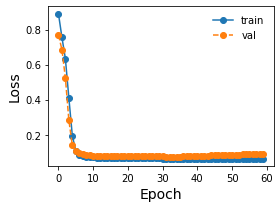

In [291]:
# Plot training history
fig,ax  = plt.subplots(figsize = (4,3))
ax.plot(history['train_loss'],color = clrs[0],linestyle = '-',label = 'train',marker = 'o')
ax.plot(history['val_loss'],color = clrs[1],linestyle = '--',label = 'val',marker = 'o')
ax.legend(frameon = False)
ax.set_xlabel('Epoch',fontsize = 14)
ax.set_ylabel('Loss',fontsize = 14)
fig.tight_layout()

## True pairwise and environmental forces on this dataset


In [292]:
def soft_lj_force(r, epsilon, sigma, rcut, lambda_param):
    n = 1
    alpha_lj = 0.5
    """Compute scalar magnitude of soft LJ/cut force for distance r."""
    if r >= rcut or r <= 1e-12:
        return 0.0
    validation_split=0.
    lam_pow_n = lambda_param ** n
    r_over_sigma = r / sigma
    r6 = r_over_sigma ** 6
    A = alpha_lj * (1 - lambda_param)**2 + r6
    dAdr = (6 * r**5) / (sigma**6)

    prefactor = 4 * epsilon * lam_pow_n
    dEdr = prefactor * (2 / A**3 - 1 / A**2) * dAdr

    return dEdr

def force_environment(x,y,kappa_x,kappa_y,x_0,y_0):
    r_vec = np.array([x-x_0,y-y_0])
    r = np.linalg.norm(r_vec)
    Fx = -kappa_x*(x-x_0)
    Fy = -kappa_y*(y-y_0)
    return np.array([Fx,Fy])
    

## Query pairwise forces

In [293]:
def get_force_at_distance(model, r):
    """
    Get the learned pairwise force magnitude at a given distance.
    
    Parameters:
    -----------
    model : ForceGNN
        Trained model
    r : float
        Distance value
    
    Returns:
    --------
    float
        Force magnitude F_r(r)
    """
    model.eval()
    with torch.no_grad():
        return model.interaction_net(torch.tensor([[r]], dtype=torch.float32)).item()

In [294]:
# Get force at a specific distance
sigma = 1.5
l_da = 0.1
rcut = sigma*2
epsilon = 0.5
r_arr = np.linspace(0.1,3.5,100)
force_infer = []
force_true = []
for r in r_arr:
    force_infer.append(get_force_at_distance(model, r))
    force_true.append(soft_lj_force(r, epsilon, sigma, rcut, l_da))

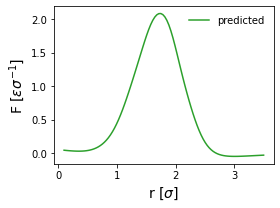

In [297]:
fig,ax  = plt.subplots(figsize = (4,3))
ax.plot(r_arr,np.multiply(force_infer,1),color = clrs[2],linestyle = '-',label = 'predicted')
#ax.plot(r_arr,list(force_true),color = 'black',linestyle = ':',label = 'actual',linewidth = 2)
ax.set_xlabel('r [$\\sigma$]',fontsize = 14)
ax.set_ylabel('F [$\\epsilon \\sigma^{-1}$]',fontsize = 14)
#ax.set_ylim([-0.2,1.5])

ax.legend(frameon = False)
fig.tight_layout()

## Evaluate model, find $R^2$

In [274]:
def evaluate_model(model, test_data, verbose=True):
    test_predictions_masked = []
    test_targets_masked = []
    index_map = []
    
    total_nodes = 0
    masked_nodes = 0

    model.eval()
    with torch.no_grad():
        for frame_idx, data_point in enumerate(test_data):
            predictions = model(
                torch.tensor(data_point['nodes']),
                torch.tensor(data_point['edges']),
                torch.tensor(data_point['edge_feat'])
            ).cpu().numpy()

            targets = data_point['targets']
            if isinstance(targets, torch.Tensor):
                targets = targets.cpu().numpy()

            if 'mask' in data_point:
                mask = data_point['mask']
                if isinstance(mask, torch.Tensor):
                    mask = mask.cpu().numpy()
            else:
                mask = np.ones(len(predictions), dtype=np.float32)

            mask_indices = mask == 1.0

            masked_pred = predictions[mask_indices]
            masked_targ = targets[mask_indices]

            test_predictions_masked.append(masked_pred)
            test_targets_masked.append(masked_targ)

            # record original indices
            node_ids = np.where(mask_indices)[0]
            index_map.extend([(frame_idx, int(n)) for n in node_ids])

            total_nodes  += len(predictions)
            masked_nodes += int(np.sum(mask_indices))

    if len(test_predictions_masked) > 0:
        test_predictions_flat = np.vstack(test_predictions_masked)
        test_targets_flat     = np.vstack(test_targets_masked)
        num_masked_nodes      = len(test_predictions_flat)

        if num_masked_nodes > 0:
            squared_errors = (test_predictions_flat - test_targets_flat) ** 2
            test_mse_x = np.mean(squared_errors[:, 0])
            test_mse_y = np.mean(squared_errors[:, 1])
            test_mse   = np.mean(squared_errors)
            test_mae   = np.mean(np.abs(test_predictions_flat - test_targets_flat))
        else:
            test_mse_x = test_mse_y = test_mse = test_mae = 0.0
    else:
        test_predictions_flat = np.zeros((0, 2), dtype=np.float32)
        test_targets_flat     = np.zeros((0, 2), dtype=np.float32)
        index_map        = []
        num_masked_nodes = 0
        test_mse_x = test_mse_y = test_mse = test_mae = 0.0

    if verbose:
        print(f"\nTest Set Evaluation (masked nodes only):")
        print(f"  Total nodes in test set: {total_nodes}")
        print(f"  Masked nodes (mask=1): {masked_nodes} ({100*masked_nodes/total_nodes:.1f}%)")
        print(f"  MSE (x-direction): {test_mse_x:.6f} (on {num_masked_nodes:.0f} masked nodes)")
        print(f"  MSE (y-direction): {test_mse_y:.6f} (on {num_masked_nodes:.0f} masked nodes)")
        print(f"  MSE (overall): {test_mse:.6f} (on {num_masked_nodes:.0f} masked nodes)")
        print(f"  MAE: {test_mae:.6f} (on {num_masked_nodes:.0f} masked nodes)")

    return {
        'mse':              test_mse,
        'mse_x':            test_mse_x,
        'mse_y':            test_mse_y,
        'mae':              test_mae,
        'predictions':      test_predictions_flat,
        'targets':          test_targets_flat,
        'index_map':        index_map,
        'num_masked_nodes': num_masked_nodes,
        'total_nodes':      total_nodes,
    }

In [275]:
evaluation = evaluate_model(model,train_data,verbose = False)
predictions = evaluation['predictions']
targets = evaluation['targets']
rsq_ax = 1-evaluation['mse_x']/np.mean((targets[:,0]-np.mean(targets[:,0]))**2)
rsq_ay = 1-evaluation['mse_y']/np.mean((targets[:,1]-np.mean(targets[:,1]))**2)
print(f"R^2 for ax: {rsq_ax:.4f}")
print(f"R^2 for ay: {rsq_ay:.4f}")
print(f"Average R^2: {(rsq_ax+rsq_ay)/2:.4f}")

R^2 for ax: 0.9465
R^2 for ay: 0.9368
Average R^2: 0.9417


## Query environmental force

In [276]:
def get_force_environment(model, x, y):
    """
    Get the learned environmental force at a given position.
    
    Parameters:
    -----------
    model : ForceGNN
        Trained model
    x : float
        x-coordinate
    y : float
        y-coordinate
    
    Returns:
    --------
    np.ndarray
        Environmental force vector [F_env_x, F_env_y]
    """
    return model.env_net(tf.constant([[x, y]], dtype=tf.float32)).numpy()[0, :]

In [277]:
def get_force_environment(model, x, y):
    """
    Get the learned environmental force at a given position.
    
    Parameters:
    -----------
    model : ForceGNN
        Trained model
    x : float
        x-coordinate
    y : float
        y-coordinate
    
    Returns:
    --------
    np.ndarray
        Environmental force vector [F_env_x, F_env_y]
    """
    model.eval()
    with torch.no_grad():
        inp = torch.tensor([[x, y]], dtype=torch.float32, device=next(model.parameters()).device)
        return model.env_net(inp).cpu().numpy()[0, :]

In [278]:
# Plot force components for a test frame
kappa_x = 0.8
kappa_y = 0.4
#gamma0 = 1/50
#doesn't F_env have a direction?
x_arr = np.linspace(0,2,50)
y_arr = np.linspace(0,2,50)
F_env_infer = np.zeros((len(x_arr),len(y_arr),2))
F_env_true = np.zeros((len(x_arr),len(y_arr),2))
for i,x in enumerate(x_arr):
    for j,y in enumerate(y_arr):
        F_env_infer[i,j,:] = get_force_environment(model, x, y) #*gamma0
        F_env_true[i,j,:] = force_environment(x,y,kappa_x,kappa_y,0,0)

# Plot force components for a test frame

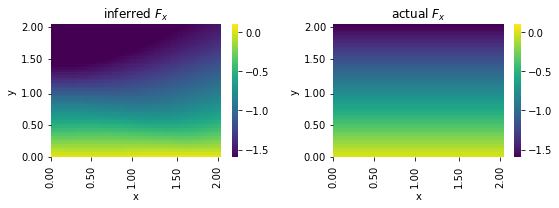

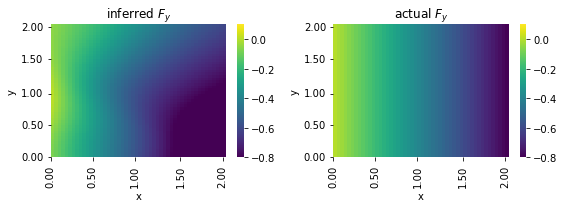

In [279]:
fig,ax = plt.subplots(1,2,figsize = (8,3))
x_ticks = np.linspace(0,2,5)
y_ticks = np.linspace(0,2,5)
x_tick_indices = [np.argmin(np.abs(x_arr - val)) for val in x_ticks]
y_tick_indices = [np.argmin(np.abs(y_arr - val)) for val in y_ticks]

# Create heatmaps
sns.heatmap(F_env_infer[:,:,0], ax=ax[0], cmap='viridis',
            xticklabels=[f'{x:.2f}' for x in x_ticks],
            yticklabels=[f'{y:.2f}' for y in y_ticks],vmin=-1.6,vmax = 0.1)

sns.heatmap(F_env_true[:,:,0], ax=ax[1], cmap='viridis',
            xticklabels=[f'{x:.2f}' for x in x_ticks],
            yticklabels=[f'{y:.2f}' for y in y_ticks],vmin=-1.6,vmax = 0.1)

# Set tick positions
for i in range(2):
    ax[i].set_xticks(x_tick_indices)
    ax[i].set_xticklabels([f'{x:.2f}' for x in x_ticks])
    ax[i].set_yticks(y_tick_indices)
    ax[i].set_yticklabels([f'{y:.2f}' for y in y_ticks])


ax[0].invert_yaxis()
ax[1].invert_yaxis()
ax[0].set_title(r'inferred $F_x$')
ax[1].set_title(r'actual $F_x$')
ax[0].set_xlabel('x')
ax[0].set_ylabel('y')
ax[1].set_xlabel('x')
ax[1].set_ylabel('y')
fig.tight_layout()
fig,ax = plt.subplots(1,2,figsize = (8,3))
sns.heatmap(F_env_infer[:,:,1], ax=ax[0], cmap='viridis',
            xticklabels=[f'{x:.2f}' for x in x_ticks],
            yticklabels=[f'{y:.2f}' for y in y_ticks],vmin=-0.8,vmax = 0.1)

sns.heatmap(F_env_true[:,:,1], ax=ax[1], cmap='viridis',
            xticklabels=[f'{x:.2f}' for x in x_ticks],
            yticklabels=[f'{y:.2f}' for y in y_ticks],vmin=-0.8,vmax = 0.1)
ax[0].invert_yaxis()
ax[1].invert_yaxis()
for i in range(2):
    ax[i].set_xticks(x_tick_indices)
    ax[i].set_xticklabels([f'{x:.2f}' for x in x_ticks])
    ax[i].set_yticks(y_tick_indices)
    ax[i].set_yticklabels([f'{y:.2f}' for y in y_ticks])
ax[0].set_title(r'inferred $F_y$')
ax[1].set_title(r'actual $F_y$')
ax[0].set_xlabel('x')
ax[0].set_ylabel('y')
ax[1].set_xlabel('x')
ax[1].set_ylabel('y')
fig.tight_layout()
